In [1]:
# tensorcircuit[cloud] version = 0.12.0 auto with numpy, need uninstall and "numpy<2.0", or complex warning
# pip install qiskit is the latest version 2.1.2 , conda install "qiskit<1" = 0.4.6
import qiskit.version
print("Qiskit version:", qiskit.version.get_version_info())

# Set "tencent_base_url" first, must be run inside Tencent WiFi
from tensorcircuit.cloud import apis
apis.set_token("lDgLDPni4XvEi0TvBCTEDzohVjRSHhH64LCR2rogLBTDwpR24QSQ1qYsMNsmtvi8xyj7Ie56A3zoxP0kpPmSWzxZT9iE5J8OQB75BPmynbnxGEaROdPeANMfxk4sFWKv.kGRTXjCvup-srLpxqzGzVHS")
apis.list_devices(state = "on")

Qiskit version: 0.46.3


Please first ``pip install -U cirq`` to enable related functionality in translation module


[tencent::simulator:tc,
 tencent::tianji_m2v16s1,
 tencent::tianji_s2,
 tencent::tianji_m2v14s4,
 tencent::tianji_m2v15s3,
 tencent::tianji_m2v14s2,
 tencent::tianji_s2v7,
 tencent::tianji_s2v6,
 tencent::tianji_m2]

/Users/AntiEntropy/miniforge3/envs/TensorCircuit/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


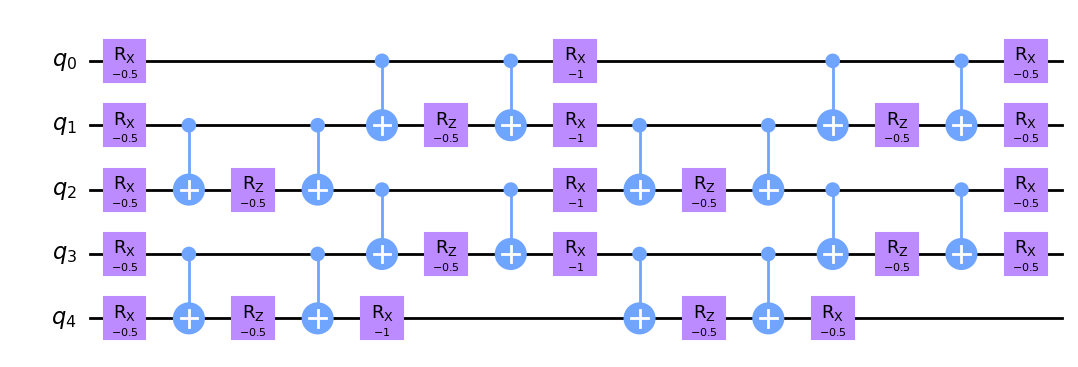

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit import QuantumRegister
from qiskit.circuit.library import RZZGate, RXGate, IGate, XGate, YGate, ZGate
from qiskit import transpile
import numpy as np
import random

h = 1
J = 0.5
t = 1

r = 2

barrier = False
# 创建 Pauli 门的列表
pauli_gates = [IGate(), XGate(), YGate(), ZGate()]
# 设置概率分布 (这里假设均匀分布，你可以根据需要修改概率值)
probabilities = [0.25, 0.25, 0.25, 0.25]

# 在需要采样 Pauli 门的地方，使用以下代码：
def sample_pauli():
    return np.random.choice(pauli_gates, p=probabilities)


# 创建一个有 5 个量子比特的寄存器
qreg = QuantumRegister(5, 'q')
qc = QuantumCircuit(qreg)
for i in range(r):
    rx_angle = - h * t / r
    if i == 0:
        # Sample Corresponding Pauli Here
        # for i in range(4):
        #     qc.append(sample_pauli , [qreg[i]])
    
        qc.append(RXGate(rx_angle), [qreg[0]])
        qc.append(RXGate(rx_angle), [qreg[1]])
        qc.append(RXGate(rx_angle), [qreg[2]])
        qc.append(RXGate(rx_angle), [qreg[3]])
        qc.append(RXGate(rx_angle), [qreg[4]])
    
    zz_angle = - J * t / r
    # 添加一层 ZZ(-0.05) 门
    # Sample Corresponding Pauli Here
    qc.append(RZZGate(2 * zz_angle), [qreg[1], qreg[2]])
    qc.append(RZZGate(2 * zz_angle), [qreg[3], qreg[4]])
    
    # 合并一层 ZZ(-0.05) 门
    # Sample Corresponding Pauli Here
    qc.append(RZZGate(2 * zz_angle), [qreg[0], qreg[1]])
    qc.append(RZZGate(2 * zz_angle), [qreg[2], qreg[3]])
    if barrier:
        qc.barrier()
    
    
    # 合并层 RX(-0.1) 门
    if i == r - 1:
        # Sample Corresponding Pauli Here
        qc.append(RXGate(rx_angle), [qreg[0]])
        qc.append(RXGate(rx_angle), [qreg[1]])
        qc.append(RXGate(rx_angle), [qreg[2]])
        qc.append(RXGate(rx_angle), [qreg[3]])
        qc.append(RXGate(rx_angle), [qreg[4]])
    else:
        # Sample Corresponding Pauli Here
        qc.append(RXGate(2 * rx_angle), [qreg[0]])
        qc.append(RXGate(2 * rx_angle), [qreg[1]])
        qc.append(RXGate(2 * rx_angle), [qreg[2]])
        qc.append(RXGate(2 * rx_angle), [qreg[3]])
        qc.append(RXGate(2 * rx_angle), [qreg[4]])
    
# 转换电路以适应特定的量子设备
qc = transpile(qc, basis_gates=['rz', 'rx', 'cx'])
qc.draw('mpl')

In [3]:
import tensorcircuit as tc
c_test = tc.Circuit(2)
c_test.h(0)
c_test.cx(0, 1)
c_test.draw()

┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

In [ ]:
import tensorcircuit as tc
# 'qiskit.circuit.Qubit' object has no attribute 'index'
c_from_qiskit = tc.Circuit.from_qiskit(qc) # need qiskit <= 1.0, can fit with barrier
c_from_qiskit.draw(idle_wires=False)

┌──────────┐                                                 ┌────────┐»
q_0: ┤ Rx(-0.5) ├──────────────────────────■───────────────────■──┤ Rx(-1) ├»
     ├──────────┤                        ┌─┴─┐   ┌──────────┐┌─┴─┐├────────┤»
q_1: ┤ Rx(-0.5) ├──■────────────────■────┤ X ├───┤ Rz(-0.5) ├┤ X ├┤ Rx(-1) ├»
     ├──────────┤┌─┴─┐┌──────────┐┌─┴─┐  └───┘   └──────────┘└───┘├────────┤»
q_2: ┤ Rx(-0.5) ├┤ X ├┤ Rz(-0.5) ├┤ X ├────■───────────────────■──┤ Rx(-1) ├»
     ├──────────┤└───┘└──────────┘└───┘  ┌─┴─┐   ┌──────────┐┌─┴─┐├────────┤»
q_3: ┤ Rx(-0.5) ├──■────────────────■────┤ X ├───┤ Rz(-0.5) ├┤ X ├┤ Rx(-1) ├»
     ├──────────┤┌─┴─┐┌──────────┐┌─┴─┐┌─┴───┴──┐└──────────┘└───┘└────────┘»
q_4: ┤ Rx(-0.5) ├┤ X ├┤ Rz(-0.5) ├┤ X ├┤ Rx(-1) ├───────────────────────────»
     └──────────┘└───┘└──────────┘└───┘└────────┘                           »
«                                                        ┌──────────┐
«q_0: ───────────────────────────■────────────────────■──┤ Rx(-0.5) ├
«                              ┌─┴─┐    ┌──────────┐┌─┴─┐├──────────┤
«q_1: ──■────────────────■─────┤ X ├────┤ Rz(-0.5) ├┤ X ├┤ Rx(-0.5) ├
«     ┌─┴─┐┌──────────┐┌─┴─┐   └───┘    └──────────┘└───┘├──────────┤
«q_2: ┤ X ├┤ Rz(-0.5) ├┤ X ├─────■────────────────────■──┤ Rx(-0.5) ├
«     └───┘└──────────┘└───┘   ┌─┴─┐    ┌──────────┐┌─┴─┐├──────────┤
«q_3: ──■────────────────■─────┤ X ├────┤ Rz(-0.5) ├┤ X ├┤ Rx(-0.5) ├
«     ┌─┴─┐┌──────────┐┌─┴─┐┌──┴───┴───┐└──────────┘└───┘└──────────┘
«q_4: ┤ X ├┤ Rz(-0.5) ├┤ X ├┤ Rx(-0.5) ├─────────────────────────────
«     └───┘└──────────┘└───┘└──────────┘

/Users/AntiEntropy/miniforge3/envs/TensorCircuit/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


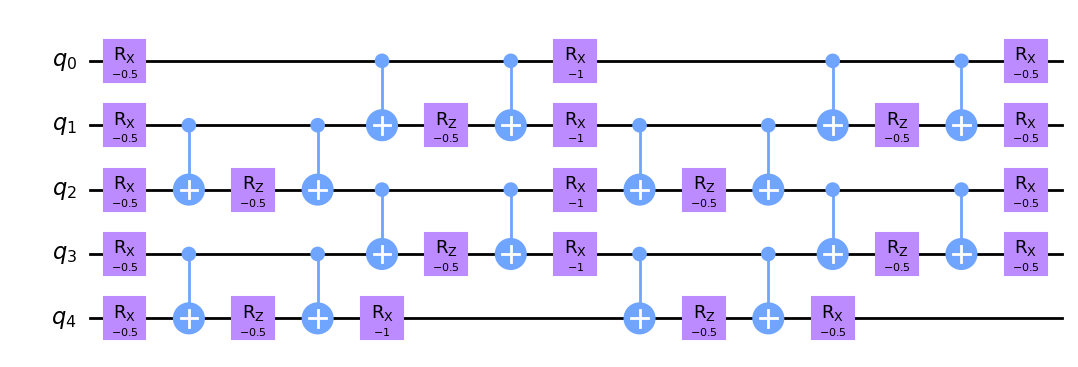

In [10]:
c_from_qasm = tc.Circuit.from_openqasm_file("qasm2/Opt_Ising_r_2.qasm") # need qiskit <= 1.0
c_from_qasm.draw(idle_wires=False)
qc2 = c_from_qasm.to_qiskit()
qc2.draw('mpl')

In [21]:
t = apis.submit_task(
    provider="tencent", 
    device="tianji_s2", 
    circuit=c_from_qiskit,
    shots=1024
)

t.results()

{'00000': 106,
 '10000': 89,
 '00001': 71,
 '00011': 64,
 '10001': 52,
 '00111': 48,
 '10011': 43,
 '00100': 41,
 '00010': 34,
 '11100': 34,
 '11001': 33,
 '11000': 32,
 '10111': 31,
 '10100': 29,
 '00110': 28,
 '11011': 28,
 '11111': 28,
 '01000': 25,
 '00101': 24,
 '10110': 23,
 '01100': 22,
 '01111': 22,
 '01001': 21,
 '10101': 20,
 '01011': 12,
 '10010': 12,
 '11101': 12,
 '11110': 11,
 '01101': 10,
 '11010': 10,
 '01010': 6,
 '01110': 3}

In [22]:
c = tc.Circuit(2)
c.h(0)
c.cx(0,1)
t = apis.submit_task(
    provider="tencent", 
    device="tianji_s2", 
    circuit=c,
    shots=1024
)

t.results()

{'00': 515, '11': 495, '10': 10, '01': 4}

In [24]:
c1 = tc.Circuit(2)
c1.h(0)
c2 = tc.Circuit(2)
c2.h(1)
ts = apis.submit_task(device="tianji_s2",
  circuit=[c1, c2],
  shots =1024
)
for t in ts:
  print(t.results())

{'1': 517, '0': 507}
{'0': 543, '1': 481}


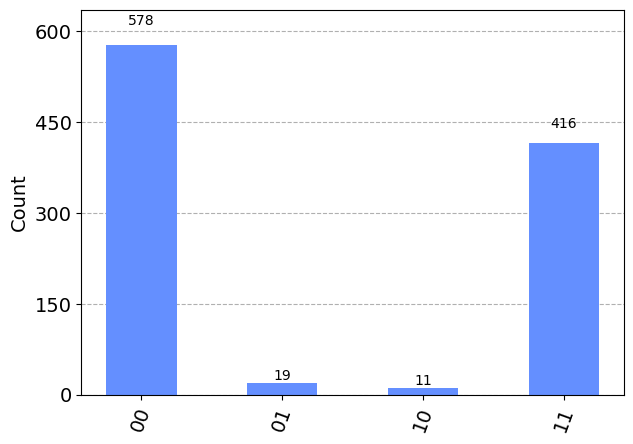

In [25]:
c = tc.Circuit(2)
c.h(0)
c.cx(0,1)
t = apis.submit_task(
    provider="tencent", 
    device="tianji_s2v7", 
    circuit=c,
    shots=1024
)

counts = t.results()
tc.results.counts.plot_histogram(counts)

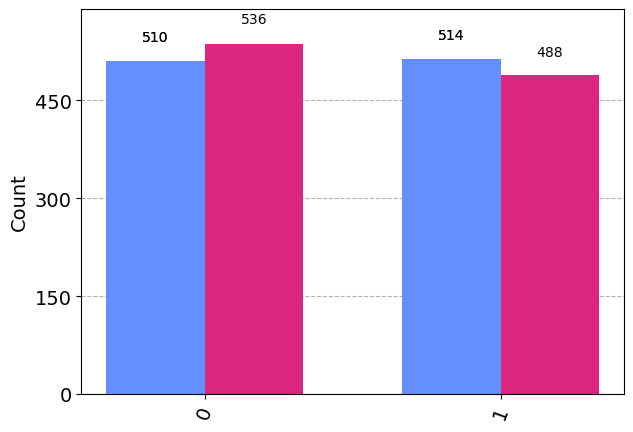

In [26]:
ts = apis.submit_task(device="tianji_s2",
  circuit=[c1, c2],
  shots=1024)

counts_list = [t.results() for t in ts]
tc.results.counts.plot_histogram(counts_list)

In [27]:
apis.set_provider("local")

t = apis.submit_task(circuit=c,
  provider="local",
  device="testing",
  shots=1024,
)

t.results()

{'11': 522, '00': 502}